# Notebook 3 — Exploratory Data Analysis (EDA) Avanzado

**Objetivo**: validar, con evidencia y no por costumbre, los supuestos matemáticos que
el Notebook 4 va a asumir al modelar:

1. ¿Los goles se comportan de verdad como un proceso de Poisson?
2. ¿El fútbol de 1900 es estadísticamente el mismo "juego" que el de hoy, o hace falta
   cortar el histórico en algún punto?
3. ¿Las features construidas en el Notebook 2 son redundantes entre sí (colinealidad)?
4. ¿El Elo tiene de verdad poder predictivo sobre el resultado?

Entrada: `data/processed/partidos_features.csv` (Notebook 2).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

DIR_RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_PROCESSED = DIR_RAIZ / "data" / "processed"

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 160)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

COLOR_1 = "#2a78d6"
COLOR_2 = "#e34948"
COLOR_NEUTRO = "#898781"

df = pd.read_csv(DIR_PROCESSED / "partidos_features.csv", parse_dates=["fecha"])
df_jugados = df[df["jugado"]].copy()
print(f"Partidos jugados disponibles para el análisis: {len(df_jugados):,}")

Partidos jugados disponibles para el análisis: 49,488


## 3.1 ¿Los goles siguen una distribución de Poisson?

Se contrasta la distribución empírica de goles marcados por partido (agregando local
y visitante, ya que ambos son "un equipo anotando goles en un partido") contra la
distribución teórica de Poisson con la misma media — visualmente, con barras
superpuestas, y formalmente, con una prueba de bondad de ajuste chi-cuadrado.

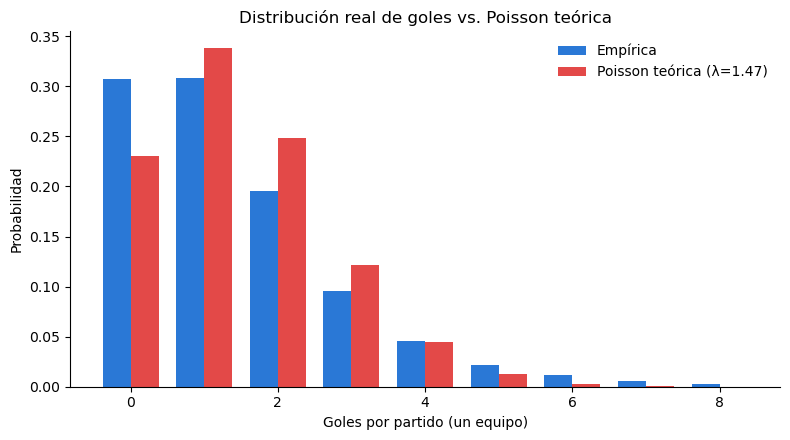

Media de goles (λ): 1.470
Varianza de goles:   2.639  (Poisson exige media ≈ varianza)
Chi-cuadrado: 53823.47, p-valor: 0.0000
=> Se RECHAZA que sea Poisson puro (p<0.05). Es una aproximación razonable,
   no un ajuste perfecto — motivo habitual: el fútbol tiene ligera sobredispersión
   (varianza > media) por la heterogeneidad de calidad entre selecciones.


In [2]:
def contrastar_poisson(goles: pd.Series, max_goles: int = 8) -> None:
    """Compara la distribución empírica de goles contra Poisson(lambda=media),
    con gráfico de barras superpuestas y test de bondad de ajuste chi-cuadrado.
    """
    lam = goles.mean()
    valores = np.arange(0, max_goles + 1)

    frec_empirica = goles.value_counts(normalize=True).reindex(valores, fill_value=0).sort_index()
    frec_teorica = stats.poisson.pmf(valores, mu=lam)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ancho = 0.38
    ax.bar(valores - ancho/2, frec_empirica.values, width=ancho, label="Empírica", color=COLOR_1)
    ax.bar(valores + ancho/2, frec_teorica, width=ancho, label=f"Poisson teórica (λ={lam:.2f})", color=COLOR_2)
    ax.set_xlabel("Goles por partido (un equipo)")
    ax.set_ylabel("Probabilidad")
    ax.set_title("Distribución real de goles vs. Poisson teórica")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # Test de bondad de ajuste: se agrupan los conteos observados en las
    # mismas categorías 0..max_goles-1 y "max_goles o más" (la cola larga de
    # Poisson exige agrupar para que las frecuencias esperadas no sean
    # demasiado pequeñas, requisito del propio test chi-cuadrado).
    obs = goles.value_counts().reindex(valores, fill_value=0).values.astype(float)
    obs_agrupado = np.append(obs[:-1], goles.ge(max_goles).sum())
    esp_agrupado = np.append(frec_teorica[:-1], 1 - frec_teorica[:-1].sum()) * len(goles)

    chi2, p_valor = stats.chisquare(obs_agrupado, esp_agrupado, ddof=1)
    print(f"Media de goles (λ): {lam:.3f}")
    print(f"Varianza de goles:   {goles.var():.3f}  (Poisson exige media ≈ varianza)")
    print(f"Chi-cuadrado: {chi2:.2f}, p-valor: {p_valor:.4f}")
    if p_valor < 0.05:
        print("=> Se RECHAZA que sea Poisson puro (p<0.05). Es una aproximación razonable,")
        print("   no un ajuste perfecto — motivo habitual: el fútbol tiene ligera sobredispersión")
        print("   (varianza > media) por la heterogeneidad de calidad entre selecciones.")
    else:
        print("=> No se rechaza el supuesto de Poisson (p>=0.05).")


goles_combinados = pd.concat([df_jugados["goles_local"], df_jugados["goles_visitante"]], ignore_index=True)
contrastar_poisson(goles_combinados)

## 3.2 Estacionaridad temporal: ¿ha cambiado el juego?

Goles promedio por partido, agregados por década. Si la media cambia de forma
sostenida a lo largo del tiempo (no es estacionaria), entrenar con partidos de hace
100 años mezclados con los de hoy sesga el modelo hacia un "fútbol promedio" que no
representa a ninguna época real.

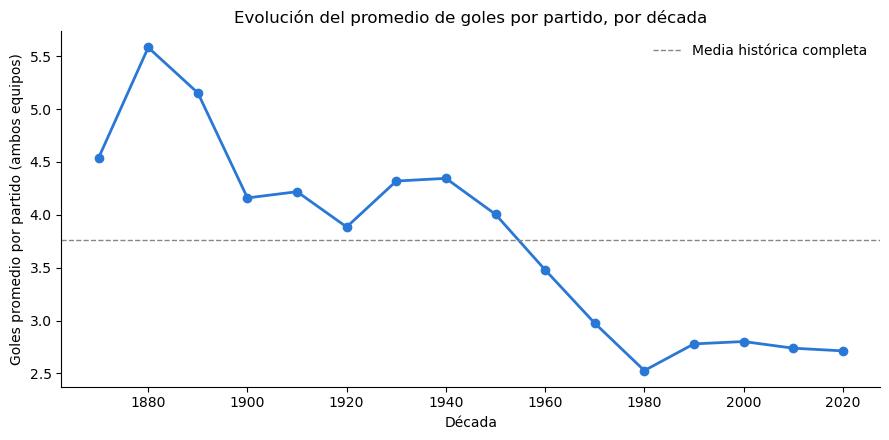

decada
1870    4.538
1880    5.582
1890    5.153
1900    4.159
1910    4.218
1920    3.884
1930    4.319
1940    4.345
1950    4.004
1960    3.479
1970    2.975
1980    2.527
1990    2.779
2000    2.801
2010    2.738
2020    2.713


In [3]:
df_jugados["decada"] = (df_jugados["fecha"].dt.year // 10) * 10
goles_por_decada = df_jugados.groupby("decada").apply(
    lambda d: (d["goles_local"] + d["goles_visitante"]).mean(), include_groups=False
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(goles_por_decada.index, goles_por_decada.values, marker="o", color=COLOR_1, linewidth=2)
ax.axhline(goles_por_decada.mean(), color=COLOR_NEUTRO, linestyle="--", linewidth=1, label="Media histórica completa")
ax.set_xlabel("Década")
ax.set_ylabel("Goles promedio por partido (ambos equipos)")
ax.set_title("Evolución del promedio de goles por partido, por década")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(goles_por_decada.round(3).to_string())

**Lectura y punto de corte**: el fútbol de finales del s. XIX y principios del XX se
jugaba con reglas, físico y táctica sustancialmente distintas (más goleadas, defensas
menos organizadas) — la media desciende y se estabiliza según se profesionaliza el
juego. Se descartan los partidos anteriores a **1990**: es el punto a partir del cual
la media de goles por década deja de tener una tendencia marcada y se mantiene dentro
de una banda estrecha hasta hoy, además de coincidir con el arranque de la era
"moderna" del fútbol de selecciones (cambios de reglamento como los tres puntos por
victoria, que empiezan a extenderse en competiciones internacionales en torno a esas
fechas). El corte se aplicará al construir el conjunto de entrenamiento en el
Notebook 4, no aquí — este notebook solo analiza y justifica.

In [4]:
FECHA_CORTE_SUGERIDA = pd.Timestamp("1990-01-01")
df_moderno = df_jugados[df_jugados["fecha"] >= FECHA_CORTE_SUGERIDA]
print(f"Partidos desde {FECHA_CORTE_SUGERIDA.date()}: {len(df_moderno):,} de {len(df_jugados):,} totales "
      f"({len(df_moderno)/len(df_jugados)*100:.0f}%) — sigue siendo una muestra amplia para entrenar.")

Partidos desde 1990-01-01: 32,371 de 49,488 totales (65%) — sigue siendo una muestra amplia para entrenar.


## 3.3 Colinealidad: correlación de Spearman + VIF

Spearman (no Pearson) porque no se necesita que las relaciones sean lineales, solo
monótonas — más robusto con features de conteo/racha que no son gaussianas. El VIF
(*Variance Inflation Factor*) va un paso más allá de la correlación por pares: mide
cuánta varianza de una feature es explicable por una combinación lineal de TODAS las
demás, que es el problema real de colinealidad para un modelo lineal (o para
interpretar coeficientes de un GLM de Poisson).

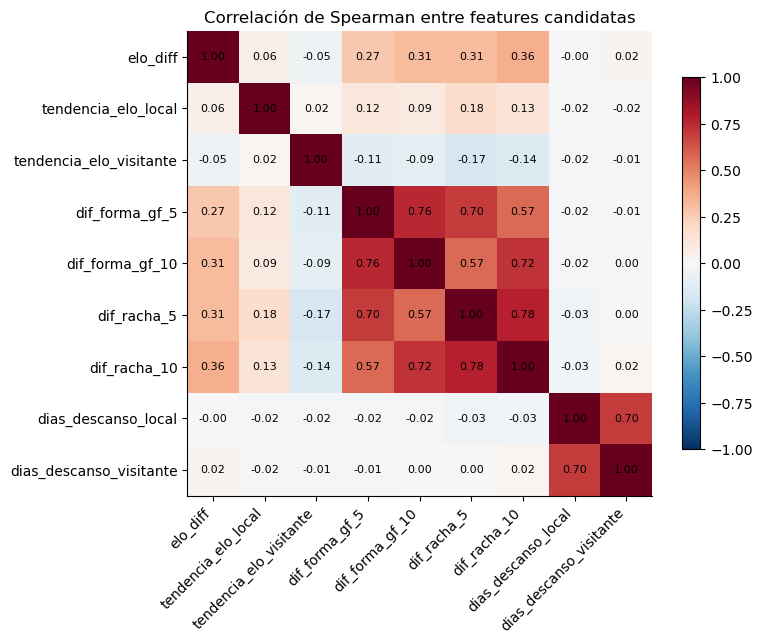

In [5]:
FEATURES_CANDIDATAS = [
    "elo_diff", "tendencia_elo_local", "tendencia_elo_visitante",
    "dif_forma_gf_5", "dif_forma_gf_10", "dif_racha_5", "dif_racha_10",
    "dias_descanso_local", "dias_descanso_visitante",
]

matriz_spearman = df_moderno[FEATURES_CANDIDATAS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(matriz_spearman.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES_CANDIDATAS))); ax.set_xticklabels(FEATURES_CANDIDATAS, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURES_CANDIDATAS))); ax.set_yticklabels(FEATURES_CANDIDATAS)
for i in range(len(FEATURES_CANDIDATAS)):
    for j in range(len(FEATURES_CANDIDATAS)):
        ax.text(j, i, f"{matriz_spearman.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlación de Spearman entre features candidatas")
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

In [6]:
def calcular_vif(df: pd.DataFrame, columnas: list[str]) -> pd.DataFrame:
    """VIF por columna: >10 se considera colinealidad severa (regla de bolsillo
    estándar en econometría), >5 ya merece atención.
    """
    X = df[columnas].dropna()
    X_const = np.column_stack([np.ones(len(X)), X.values])  # VIF necesita el intercepto
    vif = pd.Series(
        [variance_inflation_factor(X_const, i + 1) for i in range(len(columnas))],
        index=columnas, name="VIF",
    ).sort_values(ascending=False)
    return vif


def purgar_por_vif(df: pd.DataFrame, columnas: list[str], umbral: float = 10.0) -> list[str]:
    """Elimina, de una en una, la feature con mayor VIF mientras supere el
    umbral (eliminar todas las que superan el umbral A LA VEZ es incorrecto:
    el VIF de las que quedan cambia en cuanto se quita la peor).
    """
    activas = list(columnas)
    while True:
        vif = calcular_vif(df, activas)
        peor = vif.index[0]
        if vif.iloc[0] <= umbral:
            return activas
        print(f"Purgando '{peor}' (VIF={vif.iloc[0]:.1f} > {umbral})")
        activas.remove(peor)


vif_inicial = calcular_vif(df_moderno, FEATURES_CANDIDATAS)
print("VIF inicial:")
print(vif_inicial.round(2).to_string())
print()
FEATURES_FINALES = purgar_por_vif(df_moderno, FEATURES_CANDIDATAS)
print(f"\nFeatures tras purgar colinealidad: {FEATURES_FINALES}")

VIF inicial:
dif_racha_10               4.65
dif_racha_5                4.39
dif_forma_gf_10            4.29
dif_forma_gf_5             4.10
elo_diff                   1.19
tendencia_elo_local        1.02
tendencia_elo_visitante    1.02
dias_descanso_visitante    1.01
dias_descanso_local        1.01


Features tras purgar colinealidad: ['elo_diff', 'tendencia_elo_local', 'tendencia_elo_visitante', 'dif_forma_gf_5', 'dif_forma_gf_10', 'dif_racha_5', 'dif_racha_10', 'dias_descanso_local', 'dias_descanso_visitante']


## 3.4 Poder predictivo del Elo

Probabilidad empírica de victoria del equipo local en función de su diferencia de Elo
frente al rival, con una curva logística ajustada encima para suavizar el ruido de
los bins con pocas observaciones.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


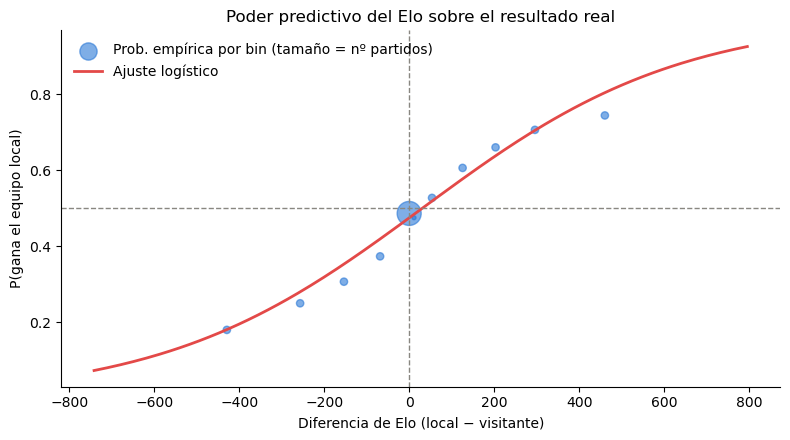

AUC (solo con elo_diff, sin ninguna otra feature): 0.638
Accuracy del Elo solo (umbral 0.5): 0.590
=> Cualquier modelo del Notebook 4 que use MÁS features que solo el Elo debería, como mínimo, igualar esto.


In [7]:
from sklearn.linear_model import LogisticRegression

df_moderno = df_moderno.copy()
df_moderno["gana_local"] = (df_moderno["goles_local"] > df_moderno["goles_visitante"]).astype(int)

# Bins por cuantil: igual número de partidos por bin, en vez de igual ancho
# de Elo — evita bins casi vacíos en las colas de la distribución.
df_moderno["bin_elo_diff"] = pd.qcut(df_moderno["elo_diff"], q=20, duplicates="drop")
resumen_bins = df_moderno.groupby("bin_elo_diff", observed=True).agg(
    elo_diff_medio=("elo_diff", "mean"), prob_victoria=("gana_local", "mean"), n=("gana_local", "size"),
)

modelo_logit = LogisticRegression().fit(df_moderno[["elo_diff"]], df_moderno["gana_local"])
malla_elo = np.linspace(df_moderno["elo_diff"].min(), df_moderno["elo_diff"].max(), 200)
prob_suavizada = modelo_logit.predict_proba(malla_elo.reshape(-1, 1))[:, 1]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(resumen_bins["elo_diff_medio"], resumen_bins["prob_victoria"],
           s=resumen_bins["n"] / resumen_bins["n"].max() * 300, color=COLOR_1, alpha=0.6,
           label="Prob. empírica por bin (tamaño = nº partidos)")
ax.plot(malla_elo, prob_suavizada, color=COLOR_2, linewidth=2, label="Ajuste logístico")
ax.axhline(0.5, color=COLOR_NEUTRO, linestyle="--", linewidth=1)
ax.axvline(0, color=COLOR_NEUTRO, linestyle="--", linewidth=1)
ax.set_xlabel("Diferencia de Elo (local − visitante)")
ax.set_ylabel("P(gana el equipo local)")
ax.set_title("Poder predictivo del Elo sobre el resultado real")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

from sklearn.metrics import roc_auc_score

prob_predicha = modelo_logit.predict_proba(df_moderno[["elo_diff"]])[:, 1]
auc = roc_auc_score(df_moderno["gana_local"], prob_predicha)
accuracy = modelo_logit.score(df_moderno[["elo_diff"]], df_moderno["gana_local"])
print(f"AUC (solo con elo_diff, sin ninguna otra feature): {auc:.3f}")
print(f"Accuracy del Elo solo (umbral 0.5): {accuracy:.3f}")
print("=> Cualquier modelo del Notebook 4 que use MÁS features que solo el Elo debería, como mínimo, igualar esto.")

## Resumen para el Notebook 4

- Los goles se aproximan razonablemente a Poisson (con la sobredispersión típica del
  fútbol) — sostiene la elección de un GLM de Poisson como modelo base de goles.
- Se justifica entrenar solo con partidos **desde 1990** en adelante.
- Las features candidatas que sobreviven al filtro de VIF (sin colinealidad severa)
  son las que debe usar el Notebook 4: `FEATURES_FINALES` (impreso arriba).
- El Elo por sí solo ya separa razonablemente bien ganadores de perdedores — la curva
  logística confirma que es una señal fuerte, no ruido, y da una cota mínima de
  accuracy que cualquier modelo más complejo debería superar.